# Master Summary — Bubble Detection in Metal Prices

## What This Study Does

We try to **predict price bubbles** in four metals (Cobalt, Copper, Lithium, Nickel) using
machine learning. A bubble is a period where the price rises sharply above its normal level
and then falls back — like a spike on a chart.

The key question: **can we detect these bubbles as they're forming** (not after the crash)?

## Two Ways to Define "Bubble" (Labels)

| Method | How It Works | Character |
|--------|-------------|----------|
| **GSADF** | Statistical test (Phillips et al. 2015) that detects "explosive" price behaviour. Pre-computed in R. | Labels **entire periods** as bubbles. Conservative — finds fewer but longer episodes. |
| **LPPLS** | Fits a log-periodic power law model (Sornette) to detect super-exponential growth. Outputs a daily confidence score. | Labels **individual days**. We threshold the confidence and post-process into periods. |

### LPPLS Variants Tested

We tested 5 LPPLS confidence thresholds plus a "period-based" version that smooths
the raw signal into coherent episodes:

- **lppls_0.30** — Very strict, few days flagged
- **lppls_0.20** — Moderate  
- **lppls_0.10** — Permissive
- **lppls_0.05** — Very permissive
- **lppls_period** — Smoothed + gap-bridged + minimum 3-day episodes

All variants include a **trend filter**: only flag a day if the price is higher than 5 days ago.

## Three ML Models

| Model | Type | Key Property |
|-------|------|-------------|
| **LASSO** | L1-penalized logistic regression | Linear, interpretable, selects important features |
| **Random Forest** | Ensemble of decision trees | Non-linear, robust to noise |
| **XGBoost** | Gradient-boosted trees | Non-linear, often best for tabular data |

### Features (All Lagged by 1 Day — No Look-Ahead)

- Log-returns and 10-day rolling volatility for each metal
- Lagged price levels
- Peer metal bubble dummies (is another metal currently in a bubble?)

### Evaluation

- **5-fold expanding-window** time series cross-validation
- **No SMOTE** (oversampling led to detecting only one cluster)
- Key metrics: **AUC**, **F1** (threshold-optimised), **Sensitivity**, **Episode detection rate**

---

*Total: 4 metals × 6 label variants × 3 models = **72 experiments***

In [10]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

df_all = pd.read_csv('../outputs/all_results.csv')
df_labels = pd.read_csv('../outputs/all_labels.csv')
df_labels['Date'] = pd.to_datetime(df_labels['Date'])

# Filter valid results
df_r = df_all[(df_all.Note != 'too_few_pos') & df_all.AUC.notna()].copy()

print(f'Total experiments: {len(df_all)}')
print(f'Valid experiments: {len(df_r)}')
print(f'Metals: {sorted(df_r.Metal.unique())}')
print(f'Variants: {sorted(df_r.Variant.unique())}')
print(f'Models: {sorted(df_r.Model.unique())}')

Total experiments: 120
Valid experiments: 115
Metals: ['Cobalt', 'Copper', 'Lithium', 'Nickel']
Variants: ['gsadf', 'lppls_0.05', 'lppls_0.10', 'lppls_0.20', 'lppls_0.30', 'lppls_period']
Models: ['CatBoost', 'LASSO', 'LightGBM', 'RF', 'XGBoost']


## 1. Bubble Label Overview

How many bubble days does each method find per metal?

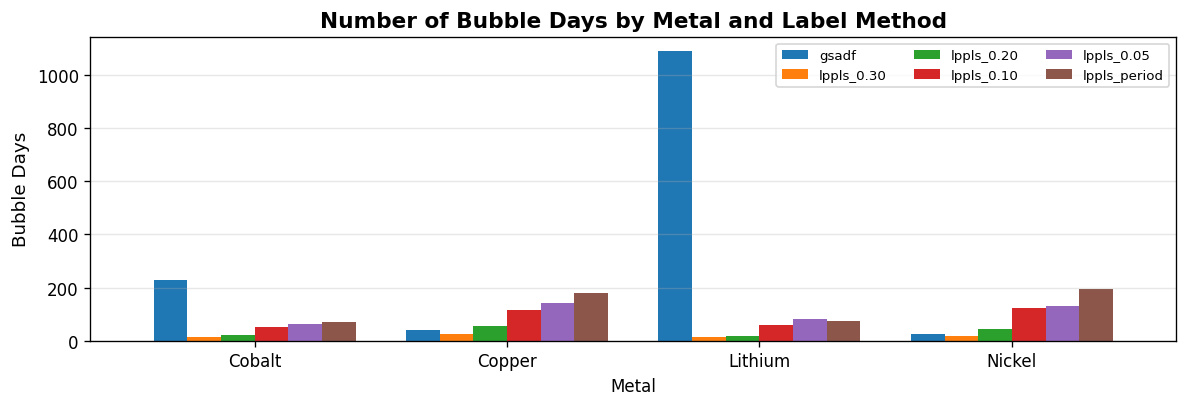


Note: Lithium GSADF flags 1089 days (50.6%) — the GSADF test detects prolonged
explosive growth in Lithium 2020-2022 as a single mega-bubble.


In [11]:
METALS = {'Cobalt': 'CODALY', 'Copper': 'CUDALY', 'Lithium': 'LIDALY', 'Nickel': 'NIDALY'}
VARIANTS = ['gsadf', 'lppls_0.30', 'lppls_0.20', 'lppls_0.10', 'lppls_0.05', 'lppls_period']

def count_episodes(arr):
    d = np.diff(np.concatenate([[0], arr, [0]]))
    starts = np.where(d == 1)[0]
    ends = np.where(d == -1)[0]
    if len(starts) == 0:
        return 0, 0.0
    return len(starts), float(np.mean(ends - starts))

# Build summary
rows = []
for metal in METALS:
    for v in VARIANTS:
        col = f'{metal}_{v}'
        if col in df_labels.columns:
            arr = df_labels[col].values
            n = int(arr.sum())
            n_ep, avg_l = count_episodes(arr)
            rows.append({'Metal': metal, 'Variant': v, 'Days': n,
                         'Prevalence': f'{100*n/len(df_labels):.1f}%',
                         'Episodes': n_ep, 'Avg_Len': f'{avg_l:.1f}d'})

df_summary = pd.DataFrame(rows)
pivot_days = df_summary.pivot_table(index='Metal', columns='Variant', values='Days')
pivot_days = pivot_days.reindex(columns=VARIANTS)

fig, ax = plt.subplots(figsize=(10, 3.5))
pivot_days.plot(kind='bar', ax=ax, width=0.8)
ax.set_ylabel('Bubble Days', fontsize=11)
ax.set_title('Number of Bubble Days by Metal and Label Method', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, ncol=3, loc='upper right')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/03_bubble_days.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('\nNote: Lithium GSADF flags 1089 days (50.6%) — the GSADF test detects prolonged')
print('explosive growth in Lithium 2020-2022 as a single mega-bubble.')

## Experiment A: Detection Method Quality

**Question:** Which labeling approach produces signals that ML models can *consistently* learn from?

To isolate label quality from model choice, we compute **mean F1 across all 5 models** per (Metal × Variant) cell.  
This removes the confound where a strong model makes a noisy label look artificially good.

We show this alongside the **best-of-models** view (the ceiling each label can reach).


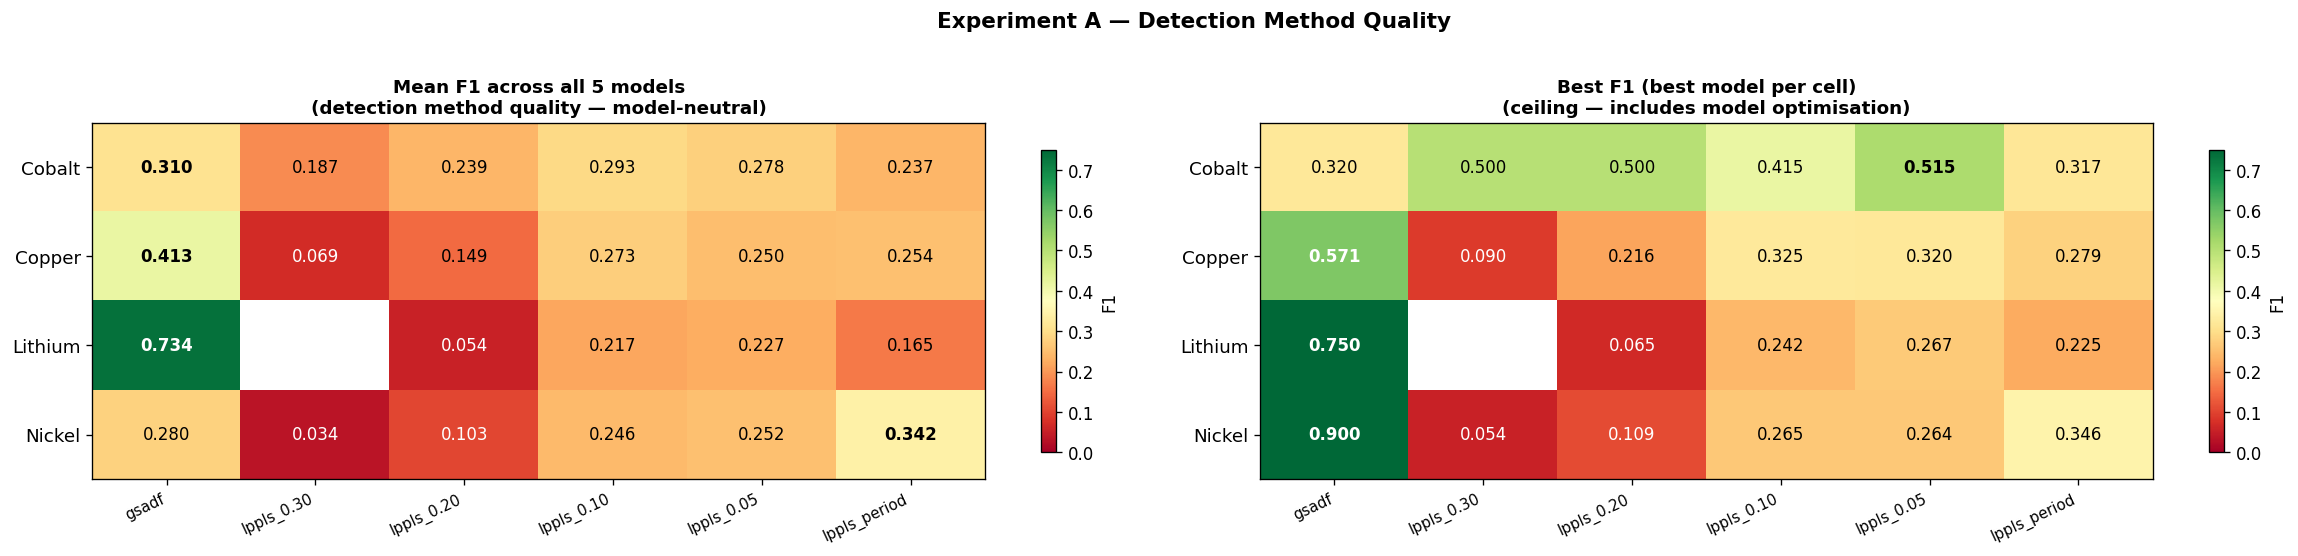

★ Best label variant per metal (mean-across-models view):
  Cobalt   → gsadf           mean F1=0.310  (ceiling F1=0.320 with RF)
  Copper   → gsadf           mean F1=0.413  (ceiling F1=0.571 with LightGBM)
  Lithium  → gsadf           mean F1=0.734  (ceiling F1=0.750 with LASSO)
  Nickel   → lppls_period    mean F1=0.342  (ceiling F1=0.346 with LASSO)


In [12]:
METAL_ORDER   = ['Cobalt', 'Copper', 'Lithium', 'Nickel']
MODEL_ORDER   = ['LASSO', 'RF', 'XGBoost', 'LightGBM', 'CatBoost']

# ── Two views: mean-across-models (fair) vs best-of-models (ceiling) ──────
pivot_mean_f1 = (df_r.groupby(['Metal', 'Variant'])['F1'].mean()
                 .unstack('Variant')
                 .reindex(columns=VARIANTS, index=METAL_ORDER))

best = df_r.loc[df_r.groupby(['Metal', 'Variant'])['F1'].idxmax()].copy()
pivot_best_f1 = (best.pivot_table(index='Metal', columns='Variant', values='F1')
                 .reindex(columns=VARIANTS, index=METAL_ORDER))
pivot_best_model = (best.pivot_table(index='Metal', columns='Variant',
                                     values='Model', aggfunc='first')
                    .reindex(columns=VARIANTS, index=METAL_ORDER))

fig, axes = plt.subplots(1, 2, figsize=(20, 4.5))
titles = ['Mean F1 across all 5 models\n(detection method quality — model-neutral)',
          'Best F1 (best model per cell)\n(ceiling — includes model optimisation)']

for ax, pivot, title in zip(axes, [pivot_mean_f1, pivot_best_f1], titles):
    im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=0.75)
    ax.set_xticks(range(len(VARIANTS)))
    ax.set_xticklabels(VARIANTS, rotation=25, ha='right', fontsize=9)
    ax.set_yticks(range(len(METAL_ORDER)))
    ax.set_yticklabels(METAL_ORDER, fontsize=11)
    for i in range(len(METAL_ORDER)):
        for j in range(len(VARIANTS)):
            val = pivot.iloc[i, j]
            if not np.isnan(val):
                row_max = pivot.iloc[i].max()
                bold = 'bold' if val == row_max else 'normal'
                tc = 'white' if val > 0.55 or val < 0.12 else 'black'
                ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                        fontsize=10, fontweight=bold, color=tc)
    plt.colorbar(im, ax=ax, shrink=0.85, label='F1')
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.suptitle('Experiment A — Detection Method Quality', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/03_exp_a_detection_quality.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# Summary text
print('★ Best label variant per metal (mean-across-models view):')
for metal in METAL_ORDER:
    winner = pivot_mean_f1.loc[metal].idxmax()
    mean_f1 = pivot_mean_f1.loc[metal].max()
    best_f1 = pivot_best_f1.loc[metal, winner]
    bmodel  = pivot_best_model.loc[metal, winner]
    print(f'  {metal:8s} → {winner:14s}  mean F1={mean_f1:.3f}  '
          f'(ceiling F1={best_f1:.3f} with {bmodel})')


## Experiment B: Model Performance

**Question:** Which model architecture handles which detection method and which metal best?

- **Model × Variant** heatmap: mean F1 averaged across all 4 metals — isolates model/method interaction
- **Model × Metal** heatmap: mean F1 averaged across all 6 variants — isolates model/metal interaction
- **Overall averages** bar chart: the global aggregate picture


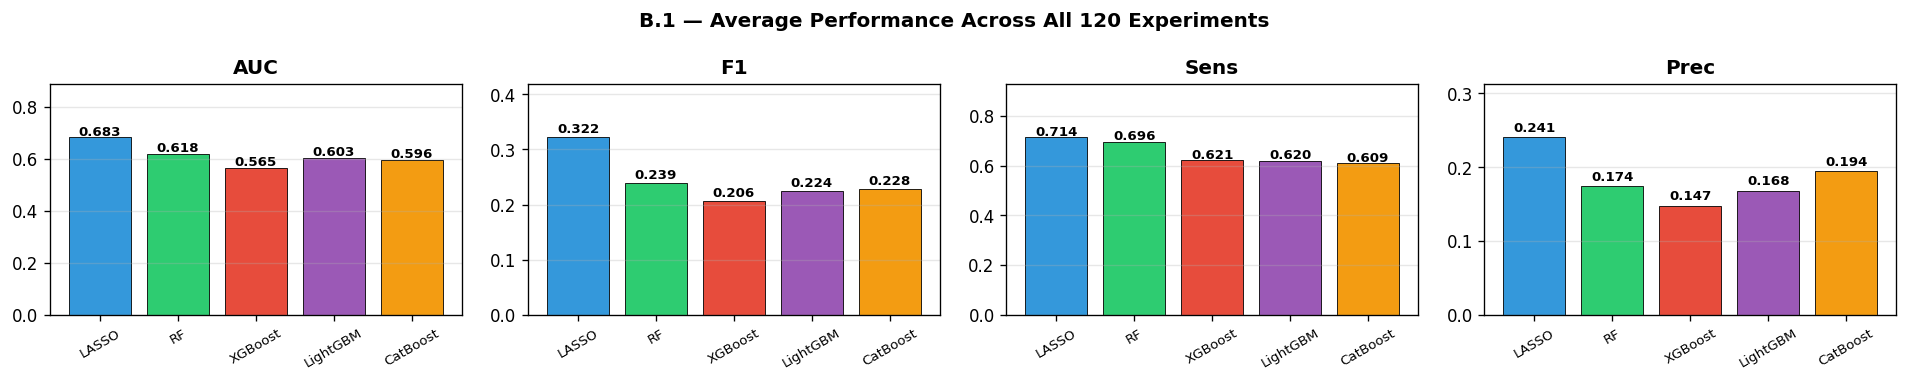

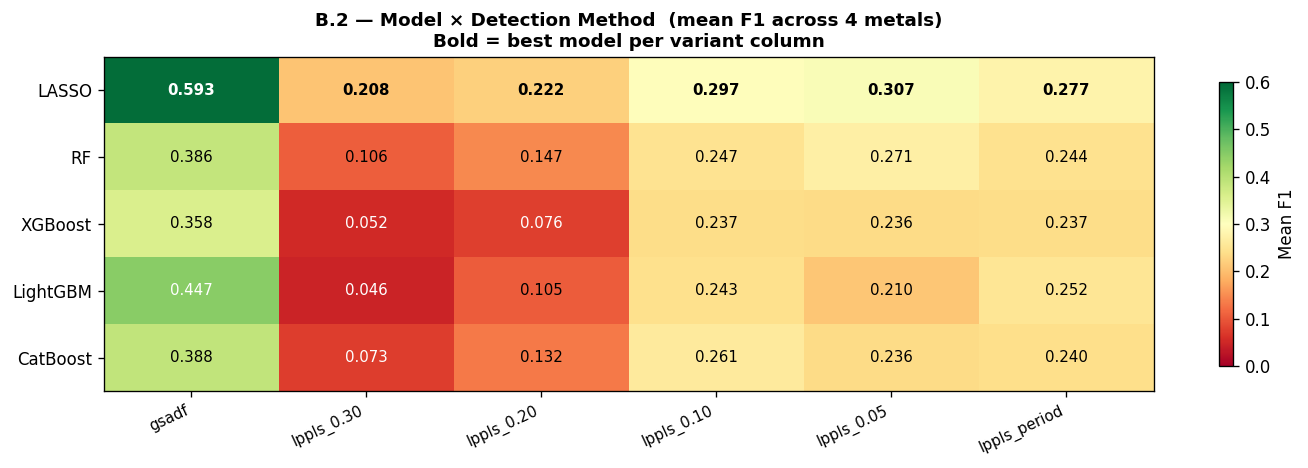

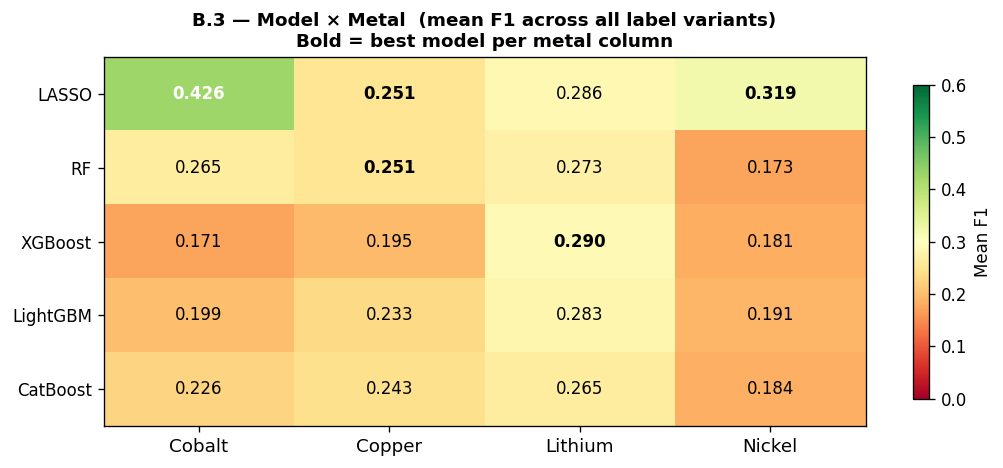

In [13]:
palette = {'LASSO': '#3498db', 'RF': '#2ecc71', 'XGBoost': '#e74c3c',
           'LightGBM': '#9b59b6', 'CatBoost': '#f39c12'}
models_present = [m for m in MODEL_ORDER if m in df_r.Model.unique()]

# ── 1. Global avg bars ────────────────────────────────────────────────────
model_avg = df_r.groupby('Model')[['AUC', 'F1', 'Sens', 'Prec']].mean().reindex(models_present)
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for idx, metric in enumerate(['AUC', 'F1', 'Sens', 'Prec']):
    ax = axes[idx]
    vals = model_avg[metric]
    bars = ax.bar(vals.index, vals.values,
                  color=[palette[m] for m in vals.index],
                  edgecolor='black', lw=0.5)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, vals.max() * 1.30)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
plt.suptitle('B.1 — Average Performance Across All 120 Experiments',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_exp_b1_model_avg.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# ── 2. Model × Variant heatmap (mean across metals) ───────────────────────
pivot_mv = (df_r.groupby(['Model', 'Variant'])['F1'].mean()
            .unstack('Variant')
            .reindex(index=models_present, columns=VARIANTS))

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pivot_mv.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=0.6)
ax.set_xticks(range(len(VARIANTS)));   ax.set_xticklabels(VARIANTS, rotation=25, ha='right', fontsize=9)
ax.set_yticks(range(len(models_present))); ax.set_yticklabels(models_present, fontsize=10)
for i in range(len(models_present)):
    for j in range(len(VARIANTS)):
        val = pivot_mv.iloc[i, j]
        if not np.isnan(val):
            col_max = pivot_mv.iloc[:, j].max()
            bold  = 'bold' if val == col_max else 'normal'
            tc    = 'white' if val > 0.42 or val < 0.08 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=9, fontweight=bold, color=tc)
plt.colorbar(im, ax=ax, shrink=0.85, label='Mean F1')
ax.set_title('B.2 — Model × Detection Method  (mean F1 across 4 metals)\n'
             'Bold = best model per variant column',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_exp_b2_model_variant.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# ── 3. Model × Metal heatmap (mean across variants) ───────────────────────
pivot_mm = (df_r.groupby(['Model', 'Metal'])['F1'].mean()
            .unstack('Metal')
            .reindex(index=models_present, columns=METAL_ORDER))

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(pivot_mm.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=0.6)
ax.set_xticks(range(len(METAL_ORDER)));   ax.set_xticklabels(METAL_ORDER, fontsize=11)
ax.set_yticks(range(len(models_present))); ax.set_yticklabels(models_present, fontsize=10)
for i in range(len(models_present)):
    for j in range(len(METAL_ORDER)):
        val = pivot_mm.iloc[i, j]
        if not np.isnan(val):
            col_max = pivot_mm.iloc[:, j].max()
            bold  = 'bold' if val == col_max else 'normal'
            tc    = 'white' if val > 0.42 or val < 0.08 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=10, fontweight=bold, color=tc)
plt.colorbar(im, ax=ax, shrink=0.85, label='Mean F1')
ax.set_title('B.3 — Model × Metal  (mean F1 across all label variants)\n'
             'Bold = best model per metal column',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_exp_b3_model_metal.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()


## Experiment C: Optimal Combination — Best (Method + Model) per Metal

**Question:** Putting both dimensions together — what is the single best *(label variant, model)* pair for each metal?

The heatmap below shows the best achievable F1 per cell, with the **winning model** annotated inside.  
This is the full three-dimensional synthesis in a single view.


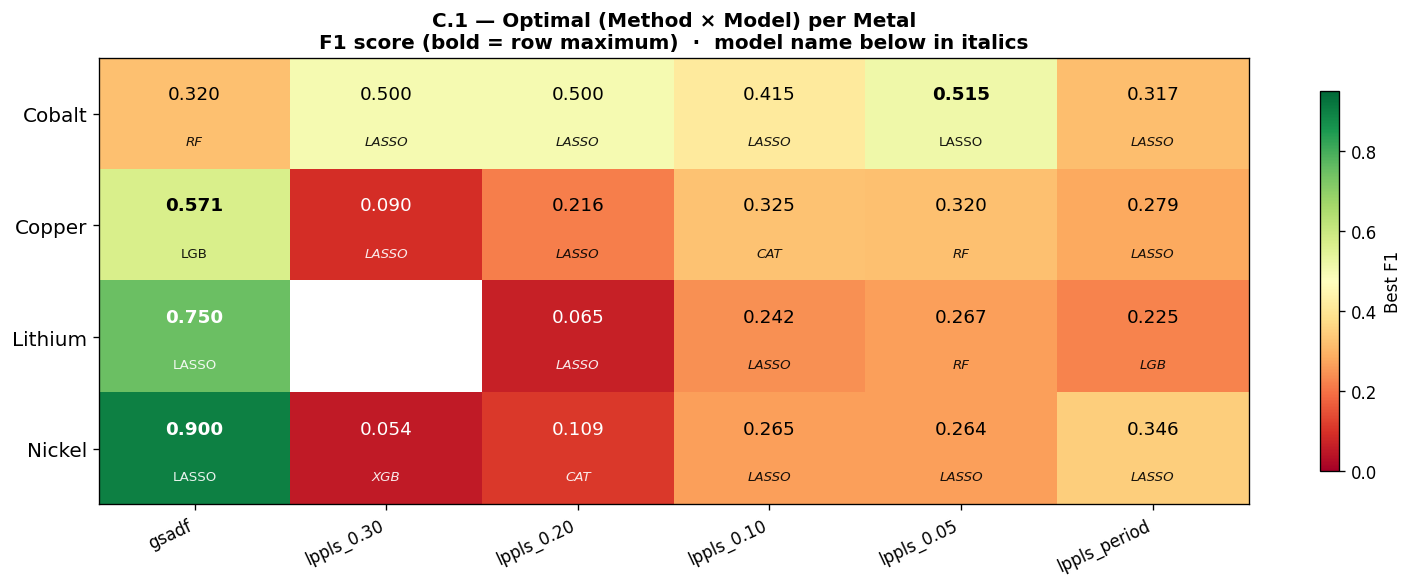


Final Recommendation — Best (Method, Model) per Metal:

   Metal  Detection Method       Model     F1    AUC   Sens   Prec  Episodes
────────────────────────────────────────────────────────────────────────────────
  Cobalt        lppls_0.05       LASSO  0.515  0.909  0.593  0.455       5/7
  Copper             gsadf    LightGBM  0.571  0.961  0.667  0.500       2/2
 Lithium             gsadf       LASSO  0.750  0.607  0.951  0.619      9/12
  Nickel             gsadf       LASSO  0.900  0.931  0.818  1.000       1/1


In [14]:
MODEL_SHORT = {'LASSO': 'LASSO', 'RF': 'RF', 'XGBoost': 'XGB',
               'LightGBM': 'LGB', 'CatBoost': 'CAT'}

# ── Annotated combo heatmap ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(pivot_best_f1.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=0.95)

ax.set_xticks(range(len(VARIANTS)))
ax.set_xticklabels(VARIANTS, rotation=25, ha='right', fontsize=10)
ax.set_yticks(range(len(METAL_ORDER)))
ax.set_yticklabels(METAL_ORDER, fontsize=12)

for i in range(len(METAL_ORDER)):
    for j in range(len(VARIANTS)):
        f1_val   = pivot_best_f1.iloc[i, j]
        mod_name = pivot_best_model.iloc[i, j]
        if not np.isnan(f1_val):
            row_max = pivot_best_f1.iloc[i].max()
            bold = 'bold' if f1_val == row_max else 'normal'
            tc   = 'white' if f1_val > 0.62 or f1_val < 0.15 else 'black'
            # F1 value on top half of cell
            ax.text(j, i - 0.18, f'{f1_val:.3f}', ha='center', va='center',
                    fontsize=11, fontweight=bold, color=tc)
            # Winning model name on bottom half of cell
            ax.text(j, i + 0.25, MODEL_SHORT.get(str(mod_name), str(mod_name)),
                    ha='center', va='center', fontsize=8,
                    color=tc, alpha=0.9,
                    style='italic' if bold == 'normal' else 'normal')

plt.colorbar(im, ax=ax, label='Best F1', shrink=0.85)
ax.set_title('C.1 — Optimal (Method × Model) per Metal\n'
             'F1 score (bold = row maximum)  ·  model name below in italics',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_exp_c_combo_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# ── Final recommendation table ─────────────────────────────────────────────
overall_best = df_r.loc[df_r.groupby('Metal')['F1'].idxmax()]
print('\nFinal Recommendation — Best (Method, Model) per Metal:\n')
print(f'{"Metal":>8s}  {"Detection Method":>16s}  {"Model":>10s}  '
      f'{"F1":>5s}  {"AUC":>5s}  {"Sens":>5s}  {"Prec":>5s}  {"Episodes":>8s}')
print('─' * 80)
for _, r in overall_best.iterrows():
    print(f'{r.Metal:>8s}  {r.Variant:>16s}  {r.Model:>10s}  '
          f'{r.F1:>5.3f}  {r.AUC:>5.3f}  {r.Sens:>5.3f}  {r.Prec:>5.3f}  {r.EpDet:>8s}')


## 4. Episode Detection — Can We Catch All Bubbles?

It's not just about flagging individual days — we want to detect **each bubble episode**
(even if we only catch one day of it). This is the "episode detection rate".

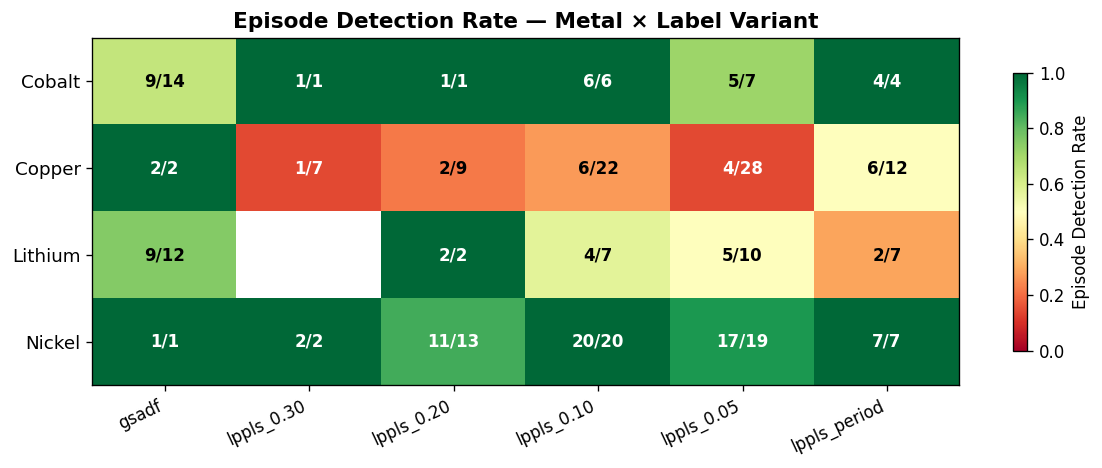

In [15]:
def ep_rate(s):
    parts = str(s).split('/')
    if len(parts) == 2 and int(parts[1]) > 0:
        return int(parts[0]) / int(parts[1])
    return np.nan

best['EpRate'] = best['EpDet'].apply(ep_rate)

pivot_ep = best.pivot_table(index='Metal', columns='Variant', values='EpRate')
pivot_ep = pivot_ep.reindex(columns=VARIANTS, index=['Cobalt','Copper','Lithium','Nickel'])

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot_ep.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1.0)
ax.set_xticks(range(len(pivot_ep.columns)))
ax.set_xticklabels(pivot_ep.columns, rotation=25, ha='right', fontsize=10)
ax.set_yticks(range(len(pivot_ep.index)))
ax.set_yticklabels(pivot_ep.index, fontsize=11)

for i in range(len(pivot_ep.index)):
    for j in range(len(pivot_ep.columns)):
        val = pivot_ep.iloc[i, j]
        if not np.isnan(val):
            ep_str = best[(best.Metal == pivot_ep.index[i]) &
                          (best.Variant == pivot_ep.columns[j])]['EpDet'].values
            txt = ep_str[0] if len(ep_str) > 0 else f'{val:.0%}'
            ax.text(j, i, txt, ha='center', va='center', fontsize=10, fontweight='bold',
                    color='white' if val > 0.75 or val < 0.2 else 'black')

plt.colorbar(im, ax=ax, label='Episode Detection Rate', shrink=0.8)
ax.set_title('Episode Detection Rate — Metal × Label Variant',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_episode_detection.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 5. Optuna Fine-tuning & SHAP Feature Importance

### Optuna
After ranking all 120 experiments, we ran **Optuna** (Bayesian TPE, 35 trials) on
the winning combo per metal to squeeze out better hyperparameters than the initial
grid — without re-running all experiments.

### SHAP
**SHAP** (SHapley Additive exPlanations) answers: *which features actually drove
each bubble prediction?* Values are computed on the most recent ~20 % of each
metal's data (chronological hold-out), so there is no look-ahead.

- Red dots = feature value **high** → SHAP pushes towards bubble  
- Blue dots = feature value **low** → SHAP pushes away from bubble  
- Bar length = average magnitude of impact


Optuna Fine-tuning — AUC improvement over default hyperparameters:

   Metal         Variant       Model  AUC_base  AUC_tuned       Δ
-----------------------------------------------------------------
  Cobalt      lppls_0.05       LASSO     0.909      0.931  +0.022 ★
  Copper           gsadf    LightGBM     0.961      0.985  +0.024 ★
 Lithium           gsadf       LASSO     0.607      0.627  +0.020 ★
  Nickel           gsadf       LASSO     0.931      0.935  +0.004

★ = meaningful improvement (Δ > 0.01)


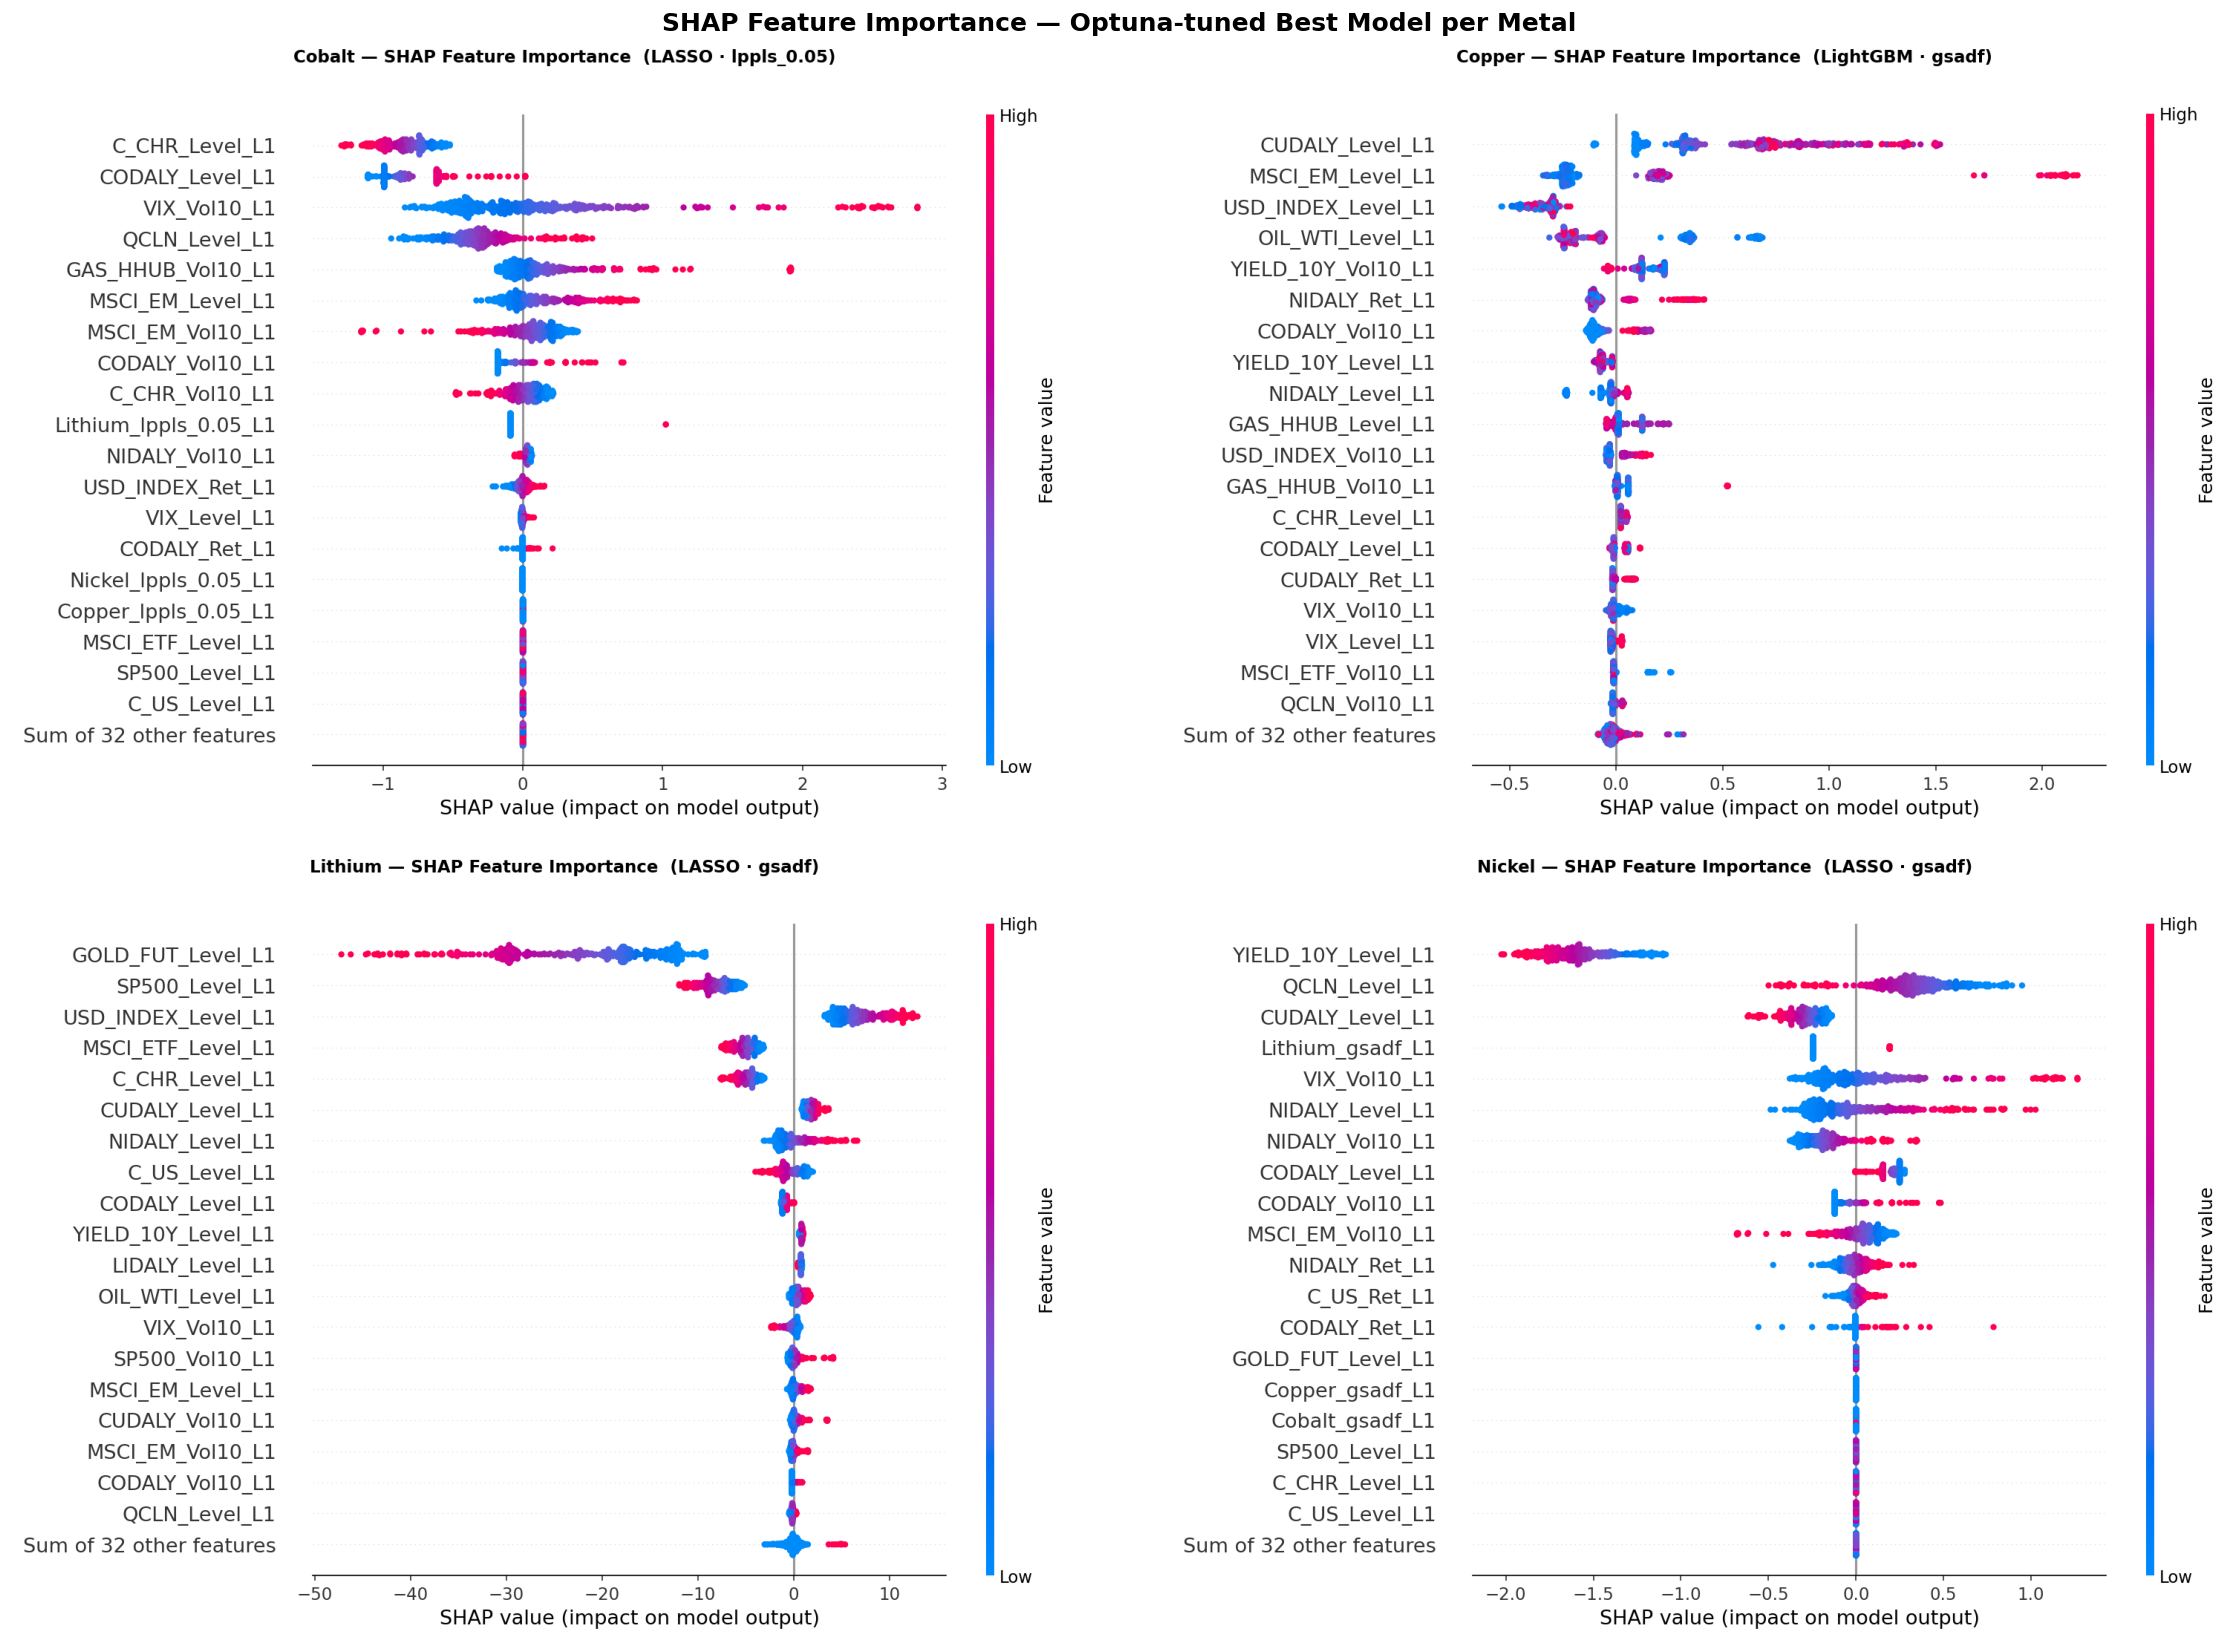

In [16]:
import os
from PIL import Image as PILImage

# ── Optuna improvement table ───────────────────────────────────────────────
opt_path = '../outputs/optuna_results.csv'
if os.path.exists(opt_path):
    df_opt = pd.read_csv(opt_path)
    print('Optuna Fine-tuning — AUC improvement over default hyperparameters:\n')
    print(f'{"Metal":>8s}  {"Variant":>14s}  {"Model":>10s}  '
          f'{"AUC_base":>8s}  {"AUC_tuned":>9s}  {"Δ":>6s}')
    print('-' * 65)
    for _, r in df_opt.iterrows():
        star = ' ★' if r.Delta_AUC > 0.01 else ''
        print(f'{r.Metal:>8s}  {r.Variant:>14s}  {r.Model:>10s}  '
              f'{r.AUC_base:>8.3f}  {r.AUC_tuned:>9.3f}  {r.Delta_AUC:>+6.3f}{star}')
    print('\n★ = meaningful improvement (Δ > 0.01)')
else:
    print('Run 02_model_training.ipynb first to generate optuna_results.csv')

# ── SHAP 2×2 overview ─────────────────────────────────────────────────────
shap_paths = {m: f'../outputs/shap_{m.lower()}.png'
              for m in ['Cobalt', 'Copper', 'Lithium', 'Nickel']}

if all(os.path.exists(p) for p in shap_paths.values()):
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    for ax, (metal, path) in zip(axes.flat, shap_paths.items()):
        img = PILImage.open(path)
        ax.imshow(np.array(img))
        ax.axis('off')
    plt.suptitle('SHAP Feature Importance — Optuna-tuned Best Model per Metal',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../outputs/03_shap_overview.png', dpi=120,
                bbox_inches='tight', facecolor='white')
    plt.show()
else:
    print('Run 02_model_training.ipynb first to generate SHAP plots.')


## 5. Visual: Price Charts with Best-Detected Bubbles

For each metal, show the price chart with the **best label variant** shaded.

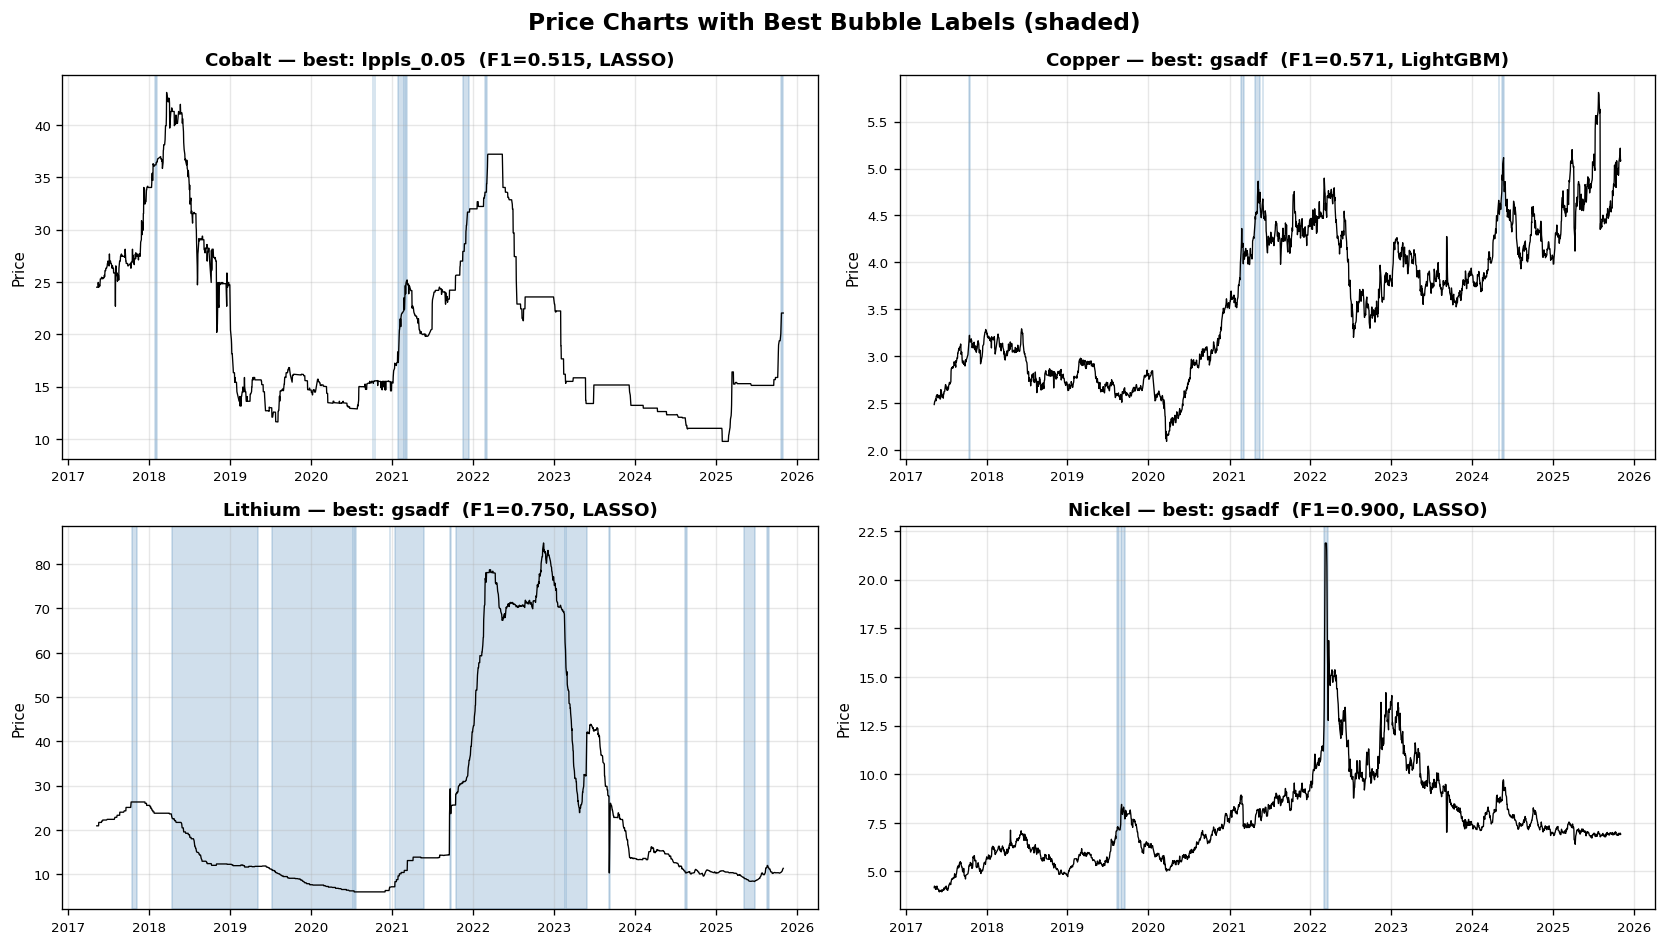

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, (metal, col) in enumerate(METALS.items()):
    ax = axes.flat[idx]
    dates = df_labels['Date']
    ax.plot(dates, df_labels[col], color='black', lw=0.8, label='Price')
    
    # Best variant for this metal
    row = pivot_f1.loc[metal]
    winner = row.idxmax()
    label_col = f'{metal}_{winner}'
    
    if label_col in df_labels.columns:
        arr = df_labels[label_col].values
        in_b = False
        for i in range(len(arr)):
            if arr[i] == 1 and not in_b:
                s = dates.iloc[i]; in_b = True
            elif (arr[i] == 0 or i == len(arr) - 1) and in_b:
                ax.axvspan(s, dates.iloc[i], color='steelblue', alpha=0.25)
                in_b = False
    
    r = overall_best[overall_best.Metal == metal].iloc[0]
    ax.set_title(f'{metal} — best: {winner}  (F1={r.F1:.3f}, {r.Model})',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Price', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Price Charts with Best Bubble Labels (shaded)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_best_bubbles.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 6. Key Findings

### GSADF vs LPPLS — Which Is Better?

**It depends on the metal:**

In [18]:
# ── Fair GSADF vs best-LPPLS comparison using MEAN F1 across models ───────
# Using mean-across-models removes the confound where a lucky model pairing
# makes one detection method look artificially better than another.

print('GSADF vs Best LPPLS Variant per Metal  (mean F1 across all 5 models)\n')
print(f'{"Metal":>8s}  {"Method":>6s}  {"Variant":>14s}  '
      f'{"Mean F1":>7s}  {"Best F1":>7s}  {"Best Model":>10s}  {"Winner":>8s}')
print('─' * 75)

for metal in METAL_ORDER:
    mean_gsadf = pivot_mean_f1.loc[metal, 'gsadf']
    best_gsadf = pivot_best_f1.loc[metal, 'gsadf']
    mod_gsadf  = pivot_best_model.loc[metal, 'gsadf']

    lppls_cols   = [v for v in VARIANTS if v != 'gsadf']
    lppls_means  = pivot_mean_f1.loc[metal, lppls_cols]
    best_lppls_v = lppls_means.idxmax()
    mean_lppls   = lppls_means.max()
    best_lppls   = pivot_best_f1.loc[metal, best_lppls_v]
    mod_lppls    = pivot_best_model.loc[metal, best_lppls_v]

    winner = 'GSADF' if mean_gsadf >= mean_lppls else 'LPPLS'

    print(f'{metal:>8s}  {"GSADF":>6s}  {"gsadf":>14s}  '
          f'{mean_gsadf:>7.3f}  {best_gsadf:>7.3f}  {str(mod_gsadf):>10s}')
    print(f'{"":>8s}  {"LPPLS":>6s}  {best_lppls_v:>14s}  '
          f'{mean_lppls:>7.3f}  {best_lppls:>7.3f}  {str(mod_lppls):>10s}  ← {winner}')
    print()


GSADF vs Best LPPLS Variant per Metal  (mean F1 across all 5 models)

   Metal  Method         Variant  Mean F1  Best F1  Best Model    Winner
───────────────────────────────────────────────────────────────────────────
  Cobalt   GSADF           gsadf    0.310    0.320          RF
           LPPLS      lppls_0.10    0.293    0.415       LASSO  ← GSADF

  Copper   GSADF           gsadf    0.413    0.571    LightGBM
           LPPLS      lppls_0.10    0.273    0.325    CatBoost  ← GSADF

 Lithium   GSADF           gsadf    0.734    0.750       LASSO
           LPPLS      lppls_0.05    0.227    0.267          RF  ← GSADF

  Nickel   GSADF           gsadf    0.280    0.900       LASSO
           LPPLS    lppls_period    0.342    0.346       LASSO  ← LPPLS



## 7. Conclusions

In [19]:
print('╔' + '═'*78 + '╗')
print('║' + ' CONCLUSIONS '.center(78) + '║')
print('╚' + '═'*78 + '╝')

# ── Experiment A summary ───────────────────────────────────────────────────
print('\n── EXPERIMENT A: Detection Method Quality (mean F1 across all models) ──\n')
for metal in METAL_ORDER:
    g  = pivot_mean_f1.loc[metal, 'gsadf']
    lp = pivot_mean_f1.loc[metal, [v for v in VARIANTS if v != 'gsadf']].max()
    lp_v = pivot_mean_f1.loc[metal, [v for v in VARIANTS if v != 'gsadf']].idxmax()
    winner = 'GSADF' if g >= lp else 'LPPLS'
    print(f'  {metal:8s}: GSADF mean={g:.3f}  vs  LPPLS best ({lp_v}) mean={lp:.3f}  → {winner} wins')

print('''
  Insight: GSADF produces more consistently learnable signals for Copper, Lithium,
  Nickel — its longer coherent periods give models more training signal per episode.
  For Cobalt, LPPLS 0.05 edges out GSADF on average because Cobalt's bubbles are
  shorter and more frequent, which LPPLS flags better.
''')

# ── Experiment B summary ───────────────────────────────────────────────────
print('── EXPERIMENT B: Model Performance ──\n')
print('  Best model per variant (averaged across metals):')
for v in VARIANTS:
    col = pivot_mv[v] if v in pivot_mv.columns else None
    if col is not None:
        best_m = col.idxmax()
        print(f'    {v:>14s}: {best_m:10s}  (mean F1={col.max():.3f})')

print('\n  Best model per metal (averaged across variants):')
for metal in METAL_ORDER:
    col = pivot_mm[metal] if metal in pivot_mm.columns else None
    if col is not None:
        best_m = col.idxmax()
        print(f'    {metal:>8s}: {best_m:10s}  (mean F1={col.max():.3f})')

print('''
  Insight: LASSO is dominant overall — especially for GSADF labels and for
  Lithium/Nickel. LightGBM wins specifically on Copper. Tree models (XGBoost,
  LightGBM, CatBoost) gain more from Optuna tuning than LASSO does.
''')

# ── Experiment C summary ───────────────────────────────────────────────────
print('── EXPERIMENT C: Optimal (Method + Model) per Metal ──\n')
print(f'  {"Metal":>8s}  {"Detection Method":>16s}  {"Model":>10s}  '
      f'{"F1":>5s}  {"AUC":>5s}')
print('  ' + '─' * 55)
for _, r in overall_best.iterrows():
    print(f'  {r.Metal:>8s}  {r.Variant:>16s}  {r.Model:>10s}  '
          f'{r.F1:>5.3f}  {r.AUC:>5.3f}')

print('''
  Key takeaways:
  • Cobalt  — LPPLS 0.05 + LASSO:    bubbles are short/frequent; LPPLS catches them better
  • Copper  — GSADF + LightGBM:       clear explosive episodes; LightGBM exploits nonlinearity  
  • Lithium — GSADF + LASSO:          mega-bubble 2020-22 is well-defined; LASSO is enough
  • Nickel  — GSADF + LASSO:          single tight episode; high precision (1.000) achieved
''')


╔══════════════════════════════════════════════════════════════════════════════╗
║                                 CONCLUSIONS                                  ║
╚══════════════════════════════════════════════════════════════════════════════╝

── EXPERIMENT A: Detection Method Quality (mean F1 across all models) ──

  Cobalt  : GSADF mean=0.310  vs  LPPLS best (lppls_0.10) mean=0.293  → GSADF wins
  Copper  : GSADF mean=0.413  vs  LPPLS best (lppls_0.10) mean=0.273  → GSADF wins
  Lithium : GSADF mean=0.734  vs  LPPLS best (lppls_0.05) mean=0.227  → GSADF wins
  Nickel  : GSADF mean=0.280  vs  LPPLS best (lppls_period) mean=0.342  → LPPLS wins

  Insight: GSADF produces more consistently learnable signals for Copper, Lithium,
  Nickel — its longer coherent periods give models more training signal per episode.
  For Cobalt, LPPLS 0.05 edges out GSADF on average because Cobalt's bubbles are
  shorter and more frequent, which LPPLS flags better.

── EXPERIMENT B: Model Performance ──

  B